In [1]:
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
import matplotlib 
%matplotlib inline

In [2]:
# data from https://docs.google.com/spreadsheets/d/100QgXtkE5FHj-EFaa64HkjYu8EddSB07/edit#gid=1566829729

# cell line IDs w/o spike-ins 2 and 3
clIDs = ['AACC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GATC', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TTCC', 'TTGG']
# spike-in 1 is GATC

# cell lines w/o spike-ins 2 and 3; added numbers (1 and 2) to cell lines w/ identical names
cell_lines = ['mT4-2D', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_line', 'Spike-in1', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
cell_line_dict = dict(zip(cell_lines, clIDs))

# samples sequenced in the second run
samples_pre_inj = ['SK1_' + '{:0.0f}'.format(i) for i in [61, 62, 63]]
samples_in_vitro = ['SK1_' + '{:0.0f}'.format(i) for i in [64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]]

In [3]:
#! ls input
! head input/SK1_61_clID_bc_extracted.txt # read line number, clID, bc
#! head input/SK1_61_find_barcodes_stats.txt

2	CAGA	AATGAGGGGTTGGCAG
3	GTTG	GGAGGCTGTGCGTAGG
4	CCTT	AGTGCGTGTGCGGTCG
5	CATG	ATGGACTGTTGGGCGG
6	ATCG	GATGATAGCGTGGATG
7	TCCA	TATGCAGGTTCGTGAG
8	ATGC	CACGTCCGTTAGACAG
9	GTTG	GTGGGTAGGCTGCGGG
10	AGCA	TGTGGTAGGGGGTGCG
11	CTTC	GGCGATCGGCAGCAAG


In [4]:
# actually, let's only look at the pre-injection data

# want to see how many reads were there per cell line in each sample + hamming distance between each two

pre_inj_pre_clust_clID_bc_count = {} 
pre_inj_pre_clust_clID_count = {}

for sample in samples_pre_inj:
    pre_inj_pre_clust_clID_bc_count[sample] = {} # a dictionary of dictionaries for each clID 
    pre_inj_pre_clust_clID_count[sample] = {} # a dictionary of counts for each clID 
      
    for line in open('input/' + sample + '_clID_bc_extracted.txt', 'r'):
        
        clID_bc = line.strip('\n').split()[1:]
        if clID_bc[0] not in pre_inj_pre_clust_clID_bc_count[sample]:
            pre_inj_pre_clust_clID_bc_count[sample][clID_bc[0]] = {} # starting a dictionary for cell line
            
        if clID_bc[1] not in pre_inj_pre_clust_clID_bc_count[sample][clID_bc[0]]: # if see barcode for the first time
            pre_inj_pre_clust_clID_bc_count[sample][clID_bc[0]][clID_bc[1]] = 1
        
        else:
            pre_inj_pre_clust_clID_bc_count[sample][clID_bc[0]][clID_bc[1]] += 1
        

    for i in clIDs:
        pre_inj_pre_clust_clID_count[sample][i] = list(pre_inj_pre_clust_clID_bc_count[sample][i].values())
    

In [5]:
#! ls output/z=-1
! head  output/z=-1/SK1_61_merged_clIDs_bc_clusters_counts.txt

AACC_TAAGTGCGGTTGGGAG	1
AACC_TACGCTGGGATGAATG	1
AACC_ACGGTCCGTGCGATTG	1
AACC_CCGGTCTGTAGGTGTG	1
AACC_GACGCGAGCCTGTGCG	2
AACC_TCGGACCGGTTGAGCG	1
AACC_CCTGCCTGGAGGATAG	1
AACC_GTTGTGCGAGGGCCAG	1
AACC_ACCGTTAGGTGGGCCG	1
AACC_CGCGCAGGGGTGCATG	1


In [6]:
# downloading post-clustering results 

pre_inj_z1_clust_clID_count = {} # only counts
pre_inj_z1_clust_clID_bc = {} # only barcodes

pre_inj_z3_clust_clID_count = {} # only counts
pre_inj_z3_clust_clID_bc = {} # only barcodes

pre_inj_z5_clust_clID_count = {} # only counts
pre_inj_z5_clust_clID_bc = {} # only barcodes

for sample in samples_pre_inj:
    pre_inj_z1_clust_clID_count[sample] = {} # a dictionary of counts for each clID 
    pre_inj_z1_clust_clID_bc[sample] = {} # a dictionary of barcodes for each clID 

    pre_inj_z3_clust_clID_count[sample] = {} # a dictionary of counts for each clID 
    pre_inj_z3_clust_clID_bc[sample] = {} # a dictionary of barcodes for each clID 

    pre_inj_z5_clust_clID_count[sample] = {} # a dictionary of counts for each clID 
    pre_inj_z5_clust_clID_bc[sample] = {} # a dictionary of barcodes for each clID 

    for line in open('output/z=-1/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        
        clID = line.strip('\n').split('_')[0]
        bc = line.strip('\n').split()[0].split('_')[-1]
        count = int(line.strip('\n').split()[-1])
        
        if clID not in pre_inj_z1_clust_clID_count[sample]:
            pre_inj_z1_clust_clID_count[sample][clID] = [] # initializing a list for cell line
            
        pre_inj_z1_clust_clID_count[sample][clID].append(count)
            
        
        if clID not in pre_inj_z1_clust_clID_bc[sample]:
            pre_inj_z1_clust_clID_bc[sample][clID] = [] # initializing a list for cell line

        pre_inj_z1_clust_clID_bc[sample][clID].append(bc)
            
    for line in open('output/z=3/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        
        clID = line.strip('\n').split('_')[0]
        bc = line.strip('\n').split()[0].split('_')[-1]
        count = int(line.strip('\n').split()[-1])
        
        if clID not in pre_inj_z3_clust_clID_count[sample]:
            pre_inj_z3_clust_clID_count[sample][clID] = [] # initializing a list for cell line
            
        pre_inj_z3_clust_clID_count[sample][clID].append(count)
            
        
        if clID not in pre_inj_z3_clust_clID_bc[sample]:
            pre_inj_z3_clust_clID_bc[sample][clID] = [] # initializing a list for cell line

        pre_inj_z3_clust_clID_bc[sample][clID].append(bc)

    for line in open('output/z=5/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        
        clID = line.strip('\n').split('_')[0]
        bc = line.strip('\n').split()[0].split('_')[-1]
        count = int(line.strip('\n').split()[-1])
        
        if clID not in pre_inj_z5_clust_clID_count[sample]:
            pre_inj_z5_clust_clID_count[sample][clID] = [] # initializing a list for cell line
            
        pre_inj_z5_clust_clID_count[sample][clID].append(count)
            
        
        if clID not in pre_inj_z5_clust_clID_bc[sample]:
            pre_inj_z5_clust_clID_bc[sample][clID] = [] # initializing a list for cell line

        pre_inj_z5_clust_clID_bc[sample][clID].append(bc)
            

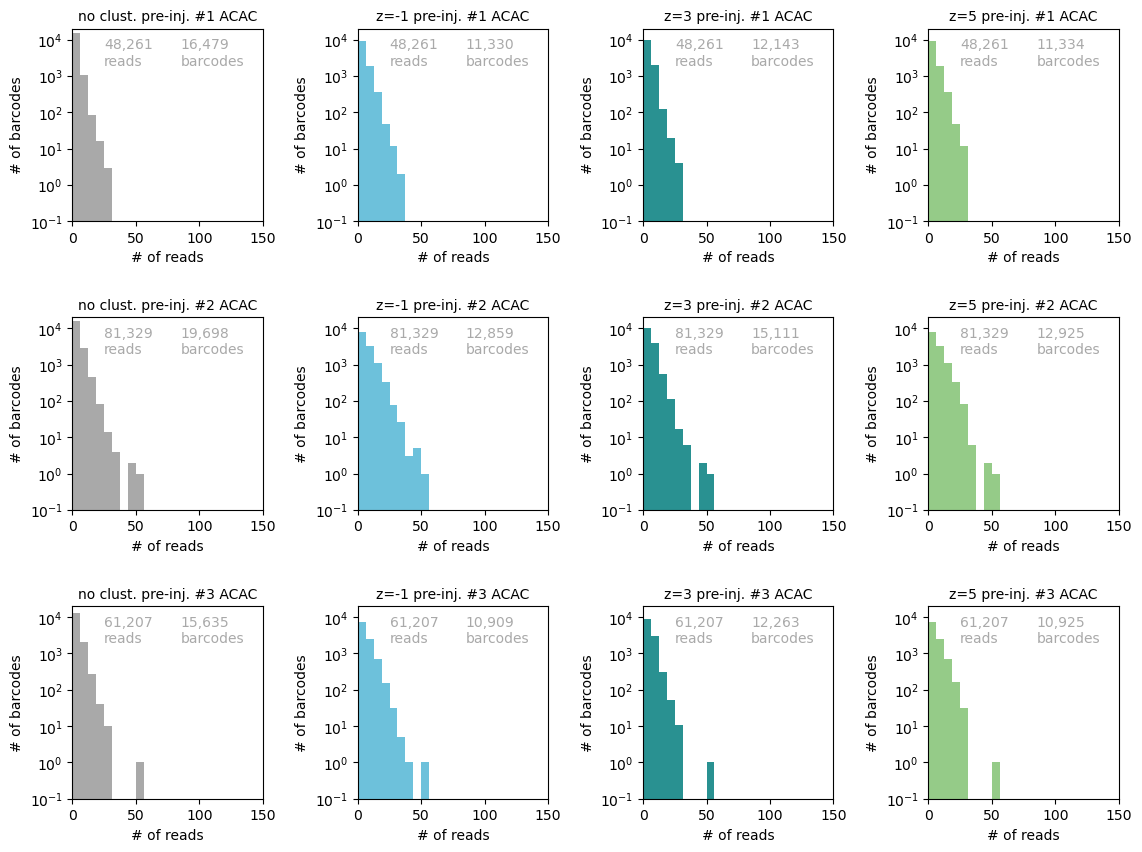

In [7]:
colors = ['#6DC1DB', '#299191', '#95CB88']

plt.figure(figsize=(3 * 4 + 1.5, 3 * 3 + 1))

grid = gridspec.GridSpec(ncols=4, nrows=3,
                         width_ratios=[1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1], hspace=0.5)

ind = 2 # clID index

for i in range(12):
    
    plt.subplot(grid[i // 4, i % 4])
        
    if i % 4 == 0: # pre-clustering
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9')
                #total_n_reads = sum([sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][x]) for x in pre_inj_pre_clust_clID_count['SK1_61'].keys() if x != 'GATC'])
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('no clust. pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)
                
                
    if i % 4 == 1: # z=-1
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                plt.hist(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[0])
                #total_n_reads = sum([sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][x]) for x in pre_inj_pre_clust_clID_count['SK1_61'].keys() if x != 'GATC'])
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('z=-1 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 2: # z=3
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                plt.hist(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[1])
                #total_n_reads = sum([sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][x]) for x in pre_inj_pre_clust_clID_count['SK1_61'].keys() if x != 'GATC'])
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('z=3 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 3: # z=5
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                plt.hist(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[2])
                #total_n_reads = sum([sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][x]) for x in pre_inj_pre_clust_clID_count['SK1_61'].keys() if x != 'GATC'])
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('z=5 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

        
#plt.savefig('plots/pre-inj_bc_distr_comparison_' + clIDs[ind] + '.png', dpi=600, bbox_inches='tight') 


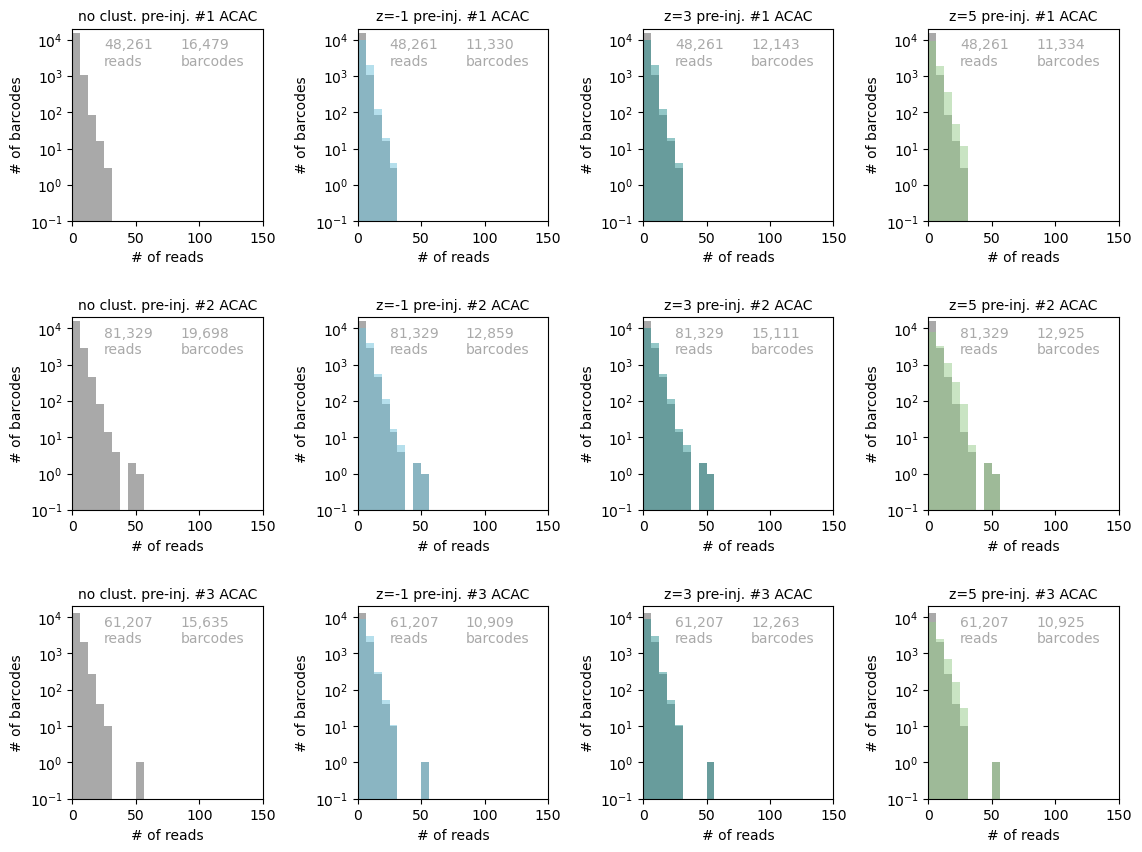

In [8]:
colors = ['#6DC1DB', '#299191', '#95CB88']

plt.figure(figsize=(3 * 4 + 1.5, 3 * 3 + 1))

grid = gridspec.GridSpec(ncols=4, nrows=3,
                         width_ratios=[1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1], hspace=0.5)

ind = 2 # clID index

for i in range(12):
    
    plt.subplot(grid[i // 4, i % 4])
        
    if i % 4 == 0: # pre-clustering
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9', alpha=1)
                            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('no clust. pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)
                
                
    if i % 4 == 1: # z=-1
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9', alpha=1)
                plt.hist(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[0], alpha=0.5)
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('z=-1 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 2: # z=3
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9', alpha=1)
                plt.hist(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[1], alpha=0.5)
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('z=3 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 3: # z=5
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9', alpha=1)
                plt.hist(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[2], alpha=0.5)

                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcodes', fontsize=10);
                plt.xlabel('# of reads', fontsize=10);
                plt.title('z=5 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

        
#plt.savefig('plots/pre-inj_bc_distr_comparison_' + clIDs[ind] + '_overlayed.png', dpi=600, bbox_inches='tight') 


In [ ]:
def hamming(x, y):
    return sum(i != j for i, j in zip(x, y))

In [20]:
ind = 2
for j in range(len(samples_pre_inj)):
    pre_clust_bc_list = np.array(list(pre_inj_pre_clust_clID_bc_count[samples_pre_inj[j]][clIDs[ind]].keys()))
    z1_clust_bc_list = np.array(pre_inj_z1_clust_clID_bc[samples_pre_inj[j]][clIDs[ind]])
    z3_clust_bc_list = np.array(pre_inj_z1_clust_clID_bc[samples_pre_inj[j]][clIDs[ind]])
    z5_clust_bc_list = np.array(pre_inj_z1_clust_clID_bc[samples_pre_inj[j]][clIDs[ind]])
    
    np.save(f"pre_clust_bc_list_{samples_pre_inj[j]}_{clIDs[ind]}.npy", pre_clust_bc_list)
    np.save(f"z=-1_clust_bc_list_{samples_pre_inj[j]}_{clIDs[ind]}.npy", z1_clust_bc_list)
    np.save(f"z=3_clust_bc_list_{samples_pre_inj[j]}_{clIDs[ind]}.npy", z3_clust_bc_list)
    np.save(f"z=5_clust_bc_list_{samples_pre_inj[j]}_{clIDs[ind]}.npy", z5_clust_bc_list)

In [ ]:
colors = ['#6DC1DB', '#299191', '#95CB88']

plt.figure(figsize=(3 * 4 + 1.5, 3 * 3 + 1))

grid = gridspec.GridSpec(ncols=4, nrows=3,
                         width_ratios=[1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1], hspace=0.5)

ind = 2 # clID index

for i in range(12):
    
    plt.subplot(grid[i // 4, i % 4])
        
    if i % 4 == 0: # pre-clustering
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                  
                bc_list = list(pre_inj_pre_clust_clID_bc_count[samples_pre_inj[j]][clIDs[ind]].keys())
                hammings = []
                for k in list(itertools.combinations(bc_list, 2)):
                    hammings.append(hamming(k[0], k[1]))
                hamming_count = [[x, hammings.count(x)] for x in set(hammings)]
                
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9', alpha=1)
                            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcode pairs', fontsize=10);
                plt.xlabel('Hamming distance', fontsize=10);
                plt.title('no clust. pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)
                
                
    if i % 4 == 1: # z=-1
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9', alpha=1)
                plt.hist(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[0], alpha=0.5)
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcode pairs', fontsize=10);
                plt.xlabel('Hamming distance', fontsize=10);
                plt.title('z=-1 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 2: # z=3
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9', alpha=1)
                plt.hist(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[1], alpha=0.5)
            
                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcode pairs', fontsize=10);
                plt.xlabel('Hamming distance', fontsize=10);
                plt.title('z=3 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

                
    if i % 4 == 3: # z=5
        for j in range(len(samples_pre_inj)):
            if i // 4 == j:
                clID_n_reads = sum(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                clID_n_bc = len(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]])
                
                plt.hist(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color='#a9a9a9', alpha=1)
                plt.hist(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind]], bins=np.linspace(0,150,25), color=colors[2], alpha=0.5)

                plt.text(25, 2e3, f"{clID_n_reads:,}" + '\nreads', color='#a9a9a9')
                plt.text(85, 2e3, f"{clID_n_bc:,}" + '\nbarcodes', color='#a9a9a9')
                plt.yscale('log'); plt.minorticks_off()
                plt.xlim(0, 150); plt.ylim(0.1, 2e4)
            
                plt.ylabel('# of barcode pairs', fontsize=10);
                plt.xlabel('Hamming distance', fontsize=10);
                plt.title('z=5 pre-inj. #' + str(j + 1) + ' ' + str(clIDs[ind]), size=10)

        
#plt.savefig('plots/pre-inj_hamming_d_comparison_' + clIDs[ind] + '_overlayed.png', dpi=600, bbox_inches='tight') 


In [ ]:
colors = ['#6DC1DB', '#299191', '#95CB88']
ind = [7, 4, 14, 2, 24, 33, 0, 17, 1, 15, 18, 29, 34, 28, 13, 5, 30, 19, 26, 11, 20, 10, 6, 27, 9, 8, 21, 16, 32, 3, 12, 31, 22, 25]

plt.figure(figsize=(8, 6))

grid = gridspec.GridSpec(ncols=1, nrows=2,
                         width_ratios=[1], wspace=0.2,
                         height_ratios=[1, 3], hspace=0.1)


plt.subplot(grid[0 // 1, 0 % 1])

for i in range(len(ind)):
    for j in range(len(samples_pre_inj)):   
        #if j !=2:
        #    continue
            
        plt.scatter(i, len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]), facecolors='black', edgecolors='none', alpha=0.2)

plt.yscale('log'); plt.minorticks_off()
plt.ylim(2e1, 5e4)

plt.xlim(-1, 34);
plt.xticks([], []);

plt.ylabel('# of barcodes\nbefore clustering', fontsize=10);




plt.subplot(grid[1 // 1, 1 % 1])

for i in range(len(ind)):
    for j in range(len(samples_pre_inj)):   
        
        if i == 0 and j == 0:
            labels = ['z=-1', 'z=3', 'z=5']
        else:
            labels = ['', '', '']
        
        plt.scatter(i, len(pre_inj_z1_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]) / len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]), facecolors=colors[0], edgecolors='none', alpha=0.7, label=labels[0])
        plt.scatter(i, len(pre_inj_z3_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]) / len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]), facecolors=colors[1], edgecolors='none', alpha=0.7, label=labels[1])
        plt.scatter(i, len(pre_inj_z5_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]) / len(pre_inj_pre_clust_clID_count[samples_pre_inj[j]][clIDs[ind[i]]]), facecolors=colors[2], edgecolors='none', alpha=0.7, label=labels[2])

plt.ylim(0.5, 1);
plt.xticks(range(len(ind)), [clID_dict[clIDs[ind[i]]].replace('_', ' ') for i in range(len(ind))], rotation=90);
plt.xlim(-1, 34);

plt.ylabel('# of barcodes normalized by\n# of barcodes before clustering', fontsize=10);

plt.legend(frameon=False, fontsize=10, loc='upper left', ncol=1);




#plt.savefig('plots/bc_loss_comparison.png', dpi=600, bbox_inches='tight') 